# WikiArt Inpainting

In [1]:
from pathlib import Path

repo_dir = Path('/content/unsupervised-learning')
branch_name = 'main'

if not repo_dir.exists():
    !git clone -b {branch_name} https://github.com/adamzsl/unsupervised-learning.git

%cd /content/unsupervised-learning
!pip install -r requirements.txt

Cloning into 'unsupervised-learning'...
remote: Enumerating objects: 385, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 385 (delta 120), reused 119 (delta 68), pack-reused 187 (from 1)
Receiving objects: 100% (385/385), 19.57 MiB | 20.37 MiB/s, done.
Resolving deltas: 100% (184/184), done.
/content/unsupervised-learning
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 122.7 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


In [2]:
import os

os.environ["COMET_API_KEY"] = "u0hUw5mvcXJNFWSbSikDgvueC"

In [3]:
from pathlib import Path
import pickle

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.utils import load_config, set_seed
from src.dataset import (
    DatasetSplits,
    WikiArtMaskedDataset,
    create_dataloaders,
    load_wikiart_splits,
)
from src.autoencoder import ConvAutoencoder, AutoencoderConfig, extract_embeddings
from src.clusterizer import (
    cluster_embeddings,
    select_optimal_pca_components,
    select_optimal_clusters,
    generate_cluster_visualization,
)
from src.inpainter import SimpleUNet, VAEInpaint, InpaintConfig, inpaint_step, log_images_to_comet
from comet_ml import Experiment

config = load_config('config.yaml')
set_seed(config['training']['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

experiment = None
exp_cfg = config.get('experiment', {})
if exp_cfg.get('use_comet', False):
    experiment = Experiment(
        project_name=exp_cfg.get('project_name', 'wikiart-inpainting'),
        workspace=exp_cfg.get('workspace') or None,
        auto_param_logging=False,
        auto_metric_logging=False,
        auto_output_logging='simple',
    )
    experiment.set_name('wikiart-inpainting-colab')
    experiment.log_parameters({
        'data.image_size': config['data']['image_size'],
        'data.batch_size': config['data']['batch_size'],
        'damage.mask_type': config['damage']['mask_type'],
        'encoder.latent_dim': config['encoder']['latent_dim'],
        'inpainting.base_channels': config['inpainting']['base_channels'],
    })
    print('Comet experiment initialized')

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorflow, torch, sklearn, keras.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


Device: cuda


COMET INFO: Experiment is live on comet.com https://www.comet.com/adam-8876/wikiart-inpainting/ae0a0365d9be46e7a28fe4b412bb2059



Comet experiment initialized


In [ ]:
print(config['encoder']['latent_dim'])

128


## 1. Wczytanie danych WikiArt

In [4]:
data_cfg = config['data']
mask_cfg = config['damage']
cluster_cfg = config.get('clustering', {})
inpaint_cfg = config.get('inpainting', {})

splits = load_wikiart_splits(
    data_cfg['dataset_name'],
    train_split=data_cfg['train_split'],
    val_split=data_cfg['val_split'],
    test_split=data_cfg['test_split'],
    seed=config['training']['seed'],
)

MAX_TRAIN = 100000
MAX_VAL = int(MAX_TRAIN/5)
MAX_TEST = int(MAX_TRAIN/5)

splits = DatasetSplits(
    train=splits.train.select(range(min(MAX_TRAIN, len(splits.train)))),
    val=splits.val.select(range(min(MAX_VAL, len(splits.val)))),
    test=splits.test.select(range(min(MAX_TEST, len(splits.test)))),
)

train_loader, val_loader, test_loader = create_dataloaders(
    splits,
    image_size=data_cfg['image_size'],
    mask_type=mask_cfg['mask_type'],
    batch_size=data_cfg['batch_size'],
    num_workers=data_cfg['num_workers'],
    max_damage_ratio=mask_cfg['max_damage_ratio'],
    min_mask_size=mask_cfg['min_mask_size'],
    max_mask_size=mask_cfg['max_mask_size'],
    brush_width=mask_cfg['brush_width'],
    num_strokes=mask_cfg['num_strokes'],
    scale_images=True,
)

cluster_loader, cluster_val_loader, cluster_test_loader = create_dataloaders(
    splits,
    image_size=data_cfg['image_size'],
    mask_type=mask_cfg['mask_type'],
    batch_size=data_cfg['batch_size'],
    num_workers=data_cfg['num_workers'],
    max_damage_ratio=mask_cfg['max_damage_ratio'],
    min_mask_size=mask_cfg['min_mask_size'],
    max_mask_size=mask_cfg['max_mask_size'],
    brush_width=mask_cfg['brush_width'],
    num_strokes=mask_cfg['num_strokes'],
    scale_images=True,
)

print('Train/Val/Test:', len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/780 [00:00<?, ?B/s]

data/train-00000-of-00007-dd79acf31a6674(…):   0%|          | 0.00/462M [00:00<?, ?B/s]

data/train-00001-of-00007-16d737d74ca9cb(…):   0%|          | 0.00/463M [00:00<?, ?B/s]

data/train-00002-of-00007-73e15989674f27(…):   0%|          | 0.00/464M [00:00<?, ?B/s]

...

data/train-00005-of-00007-053e48131b243e(…):   0%|          | 0.00/465M [00:00<?, ?B/s]

data/train-00006-of-00007-daeb2ac40cedae(…):   0%|          | 0.00/464M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/103250 [00:00<?, ? examples/s]

Train/Val/Test: 72274 15488 15488


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
from pathlib import Path
import pickle
import numpy as np
import torch

from src.autoencoder import ConvAutoencoder, AutoencoderConfig

models_dir = Path("models")
ae_path = models_dir / "autoencoder.pth"
labels_path = models_dir / "train_cluster_labels.npy"
artifacts_path = models_dir / "cluster_artifacts.pkl"

# Autoencoder (optional; used for cluster preview / choosing cluster for a sample)
autoencoder = None
if ae_path.exists():
    enc_cfg = config.get("encoder", {})
    auto_cfg = AutoencoderConfig(
        input_channels=3,
        latent_dim=enc_cfg.get("latent_dim", config["encoder"]["latent_dim"]),
        image_size=data_cfg["image_size"],
        base_channels=enc_cfg.get("base_channels"),
        use_dropout=False,
    )
    autoencoder = ConvAutoencoder(auto_cfg).to(device)
    autoencoder.load_state_dict(torch.load(ae_path, map_location=device))
    autoencoder.eval()
    print(f"Loaded autoencoder weights: {ae_path}")
else:
    print(f"Autoencoder weights not found: {ae_path} (run section 2 if you need it)")

# Cluster labels + artifacts (required for section 5 fine-tuning per cluster)
labels = None
artifacts = None

if labels_path.exists():
    labels = np.load(labels_path)
    print(f"Loaded cluster labels: {labels_path} | shape={labels.shape} | unique={np.unique(labels)}")
else:
    print(f"Cluster labels not found: {labels_path} (run section 3 before section 5)")

if artifacts_path.exists():
    with open(artifacts_path, "rb") as f:
        artifacts = pickle.load(f)
    print(f"Loaded cluster artifacts: {artifacts_path}")
else:
    print(f"Cluster artifacts not found: {artifacts_path} (run section 3 before section 5)")

# Sanity check: labels must match the current splits.train length
if labels is not None:
    n_train = len(splits.train)
    if len(labels) != n_train:
        raise ValueError(
            f"labels length ({len(labels)}) != len(splits.train) ({n_train}). "
            "Ensure labels were generated for the same train split (MAX_TRAIN/seed/etc.)."
        )
    print("Sanity check OK: labels match splits.train")

Loaded autoencoder weights: models/autoencoder.pth
Loaded cluster labels: models/train_cluster_labels.npy | shape=(72274,) | unique=[0 1 2 3 4 5 6 7]
Loaded cluster artifacts: models/cluster_artifacts.pkl
Sanity check OK: labels match splits.train


## 2. Trening autoenkodera (ekstrakcja cech)
Autoenkoder służy do uzyskania reprezentacji obrazu, które później klasteryzujemy.


In [ ]:
from pathlib import Path
from torch import nn
from tqdm import tqdm

enc_cfg = config.get('encoder', {})

auto_cfg = AutoencoderConfig(
    input_channels=3,
    latent_dim=enc_cfg.get('latent_dim', config['encoder']['latent_dim']),
    image_size=data_cfg['image_size'],
    base_channels=enc_cfg.get('base_channels'),
    use_dropout=False,
)

autoencoder = ConvAutoencoder(auto_cfg).to(device)
optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=config['encoder']['learning_rate'],
)
criterion = nn.L1Loss()

EPOCHS = 5

for epoch in range(1, EPOCHS + 1):
    autoencoder.train()
    running_loss = 0.0

    for images, _, _, _ in tqdm(train_loader, desc=f'Train {epoch}/{EPOCHS}'):
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        recon, _ = autoencoder(images)
        loss = criterion(recon, images)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch}: train_loss={epoch_loss:.4f}')

    if experiment is not None:
        experiment.log_metric(
            'autoencoder_train_loss',
            epoch_loss,
            step=epoch,
        )

Path('models').mkdir(exist_ok=True)
torch.save(autoencoder.state_dict(), 'models/autoencoder.pth')

Train 1/5: 100%|██████████| 157/157 [00:37<00:00,  4.22it/s]


Epoch 1: train_loss=0.1648


Train 2/5: 100%|██████████| 157/157 [00:30<00:00,  5.16it/s]


Epoch 2: train_loss=0.1246


Train 3/5: 100%|██████████| 157/157 [00:29<00:00,  5.35it/s]


Epoch 3: train_loss=0.1107


Train 4/5: 100%|██████████| 157/157 [00:30<00:00,  5.14it/s]


Epoch 4: train_loss=0.1022


Train 5/5: 100%|██████████| 157/157 [00:29<00:00,  5.34it/s]


Epoch 5: train_loss=0.0972


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


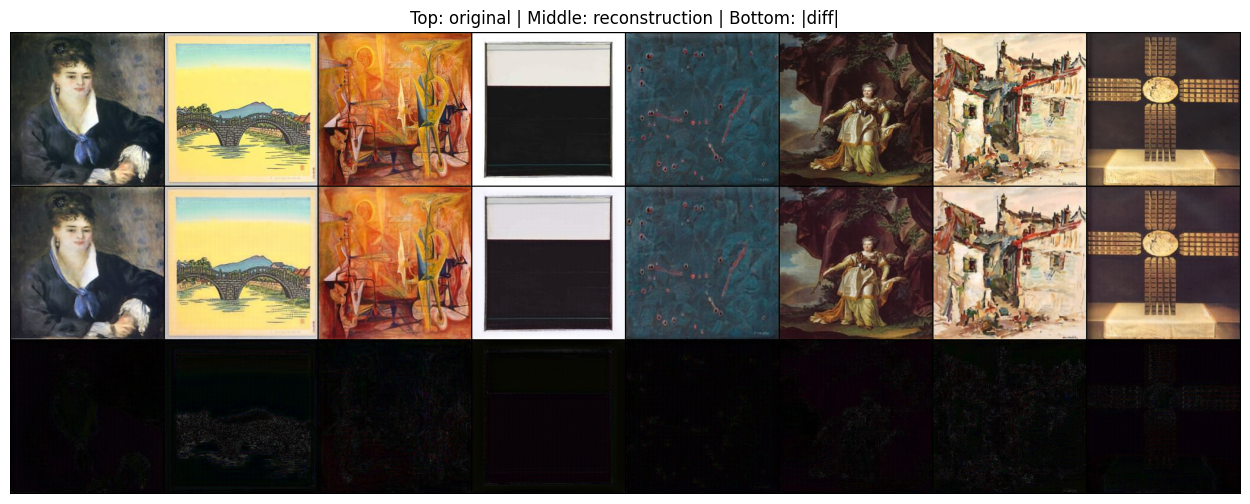

In [20]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

auto_cfg = AutoencoderConfig(
    input_channels=3,
    latent_dim=config['encoder']['latent_dim'],
    image_size=data_cfg['image_size'],
    base_channels=config.get('encoder', {}).get('base_channels', None),
)

autoencoder = ConvAutoencoder(auto_cfg).to(device)
autoencoder.load_state_dict(torch.load('models/autoencoder.pth', map_location=device))
autoencoder.eval()

N = 8  # liczba obrazów do pokazania

with torch.no_grad():
    images, _, _, _ = next(iter(val_loader))
    images = images.to(device)
    recon, _ = autoencoder(images)

images = images[:N].cpu()
recon = recon[:N].cpu()
diff = (images - recon).abs()

grid = make_grid(torch.cat([images, recon, diff], dim=0), nrow=N, normalize=True)
plt.figure(figsize=(2 * N, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Top: original | Middle: reconstruction | Bottom: |diff|")
plt.show()


## 3. Ekstrakcja embeddingów i klasteryzacja
Z embeddingów tworzymy klastry, które wykorzystamy do fine-tuningu inpaintera.


In [ ]:
MAX_EMBED = 2000
embed_split = splits.train.select(range(min(MAX_EMBED, len(splits.train))))

embedding_loader = DataLoader(
    WikiArtMaskedDataset(
        embed_split,
        image_size=data_cfg['image_size'],
        mask_type=mask_cfg['mask_type'],
        max_damage_ratio=mask_cfg['max_damage_ratio'],
        min_mask_size=mask_cfg['min_mask_size'],
        max_mask_size=mask_cfg['max_mask_size'],
        brush_width=mask_cfg['brush_width'],
        num_strokes=mask_cfg['num_strokes'],
        scale_images=True,
    ),
    batch_size=data_cfg['batch_size'],
    shuffle=False,
    num_workers=data_cfg['num_workers'],
)

autoencoder.eval()
embeddings = extract_embeddings(autoencoder, embedding_loader, device)
print('Embeddings shape:', tuple(embeddings.shape))
embeddings_np = embeddings.cpu().numpy()
if embeddings_np.ndim > 2:
    embeddings_np = embeddings_np.reshape(embeddings_np.shape[0], -1)

pca_components = cluster_cfg.get('pca_components')
if pca_components is None:
    pca_components, pca_fig = select_optimal_pca_components(
        embeddings_np,
        variance_threshold=cluster_cfg.get('pca_variance_threshold', 0.95),
        max_components=cluster_cfg.get('pca_max_components', 128),
        min_components=cluster_cfg.get('pca_min_components', 16),
    )
    plt.show()

n_clusters = cluster_cfg.get('n_clusters')
if n_clusters is None:
    n_clusters, cluster_fig = select_optimal_clusters(
        embeddings_np,
        k_min=cluster_cfg.get('k_min', 2),
        k_max=cluster_cfg.get('k_max', 12),
        pca_components=pca_components,
        pca_variance_threshold=cluster_cfg.get('pca_variance_threshold'),
    )
    plt.show()

labels_subset, artifacts = cluster_embeddings(
    embeddings_np,
    method=cluster_cfg.get('method', 'kmeans'),
    n_clusters=n_clusters,
    pca_components=pca_components,
    pca_variance_threshold=cluster_cfg.get('pca_variance_threshold'),
    pca_max_components=cluster_cfg.get('pca_max_components', 128),
    pca_min_components=cluster_cfg.get('pca_min_components', 16),
)

full_loader = DataLoader(
    WikiArtMaskedDataset(
        splits.train,
        image_size=data_cfg['image_size'],
        mask_type=mask_cfg['mask_type'],
        max_damage_ratio=mask_cfg['max_damage_ratio'],
        min_mask_size=mask_cfg['min_mask_size'],
        max_mask_size=mask_cfg['max_mask_size'],
        brush_width=mask_cfg['brush_width'],
        num_strokes=mask_cfg['num_strokes'],
        scale_images=True,
    ),
    batch_size=data_cfg['batch_size'],
    shuffle=False,
    num_workers=data_cfg['num_workers'],
)

labels_full = []
with torch.no_grad():
    for batch in tqdm(full_loader, desc='Assign clusters'):
        images = batch[0].to(device)

        z = autoencoder.encode(images)
        z_vec = z.mean(dim=(2, 3))
        z = z_vec.cpu().numpy()

        z_scaled = artifacts.scaler.transform(z)
        z_reduced = artifacts.pca.transform(z_scaled)
        preds = artifacts.model.predict(z_reduced)

        labels_full.append(preds)

labels = np.concatenate(labels_full, axis=0)
np.save('models/train_cluster_labels.npy', labels)
with open('models/cluster_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Cluster labels:', np.unique(labels))


Cluster labels: [0 1 2 3 4 5 6 7]


## 3.1 Podgląd klastrów

In [6]:
import numpy as np
import matplotlib.pyplot as plt

cluster_viz = generate_cluster_visualization(
    embeddings_np,
    n_clusters=n_clusters,
    method='both',
)
for fig in cluster_viz.values():
    display(fig)

unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(unique_labels, counts)
plt.title('Liczba obrazów w klastrach')
plt.xlabel('Klaster')
plt.ylabel('Liczba obrazów')
plt.show()

samples_per_cluster = 4
max_clusters = min(8, len(unique_labels))
show_clusters = unique_labels[:max_clusters]

sample_ds = WikiArtMaskedDataset(
    splits.train,
    image_size=data_cfg['image_size'],
    mask_type=mask_cfg['mask_type'],
    max_damage_ratio=mask_cfg['max_damage_ratio'],
    min_mask_size=mask_cfg['min_mask_size'],
    max_mask_size=mask_cfg['max_mask_size'],
    brush_width=mask_cfg['brush_width'],
    num_strokes=mask_cfg['num_strokes'],
    scale_images=True,
)

fig, axes = plt.subplots(len(show_clusters), samples_per_cluster, figsize=(3 * samples_per_cluster, 3 * len(show_clusters)))
if len(show_clusters) == 1:
    axes = np.expand_dims(axes, 0)

for r, cid in enumerate(show_clusters):
    idxs = np.where(labels == cid)[0]
    if len(idxs) == 0:
        continue
    chosen = np.random.choice(idxs, size=min(samples_per_cluster, len(idxs)), replace=False)
    for c in range(samples_per_cluster):
        if c < len(chosen):
            img, _, _, _ = sample_ds[int(chosen[c])]
            axes[r, c].imshow(img.permute(1, 2, 0).clamp(0, 1))
            axes[r, c].set_title(f'Cluster {int(cid)}')
        axes[r, c].axis('off')

plt.tight_layout()
plt.show()


NameError: name 'embeddings_np' is not defined

## 4. Trening bazowego modelu inpainting
Najpierw uczymy model na całym zbiorze, a potem możemy go dostroić per-klaster.


In [8]:
inpaint_config = InpaintConfig(
    base_channels=inpaint_cfg.get("base_channels", config["inpainting"]["base_channels"]),
    latent_dim=inpaint_cfg.get("latent_dim", 128),
    output_scale=inpaint_cfg.get("output_scale", 1.0),
)

inpaint_model = SimpleUNet(inpaint_config).to(device)

INPAINT_EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
LOG_INTERVAL = 50
GRAD_CLIP_NORM = 1.0
USE_AMP = True  # działa tylko na CUDA

# Early stopping + best checkpoint
PATIENCE = 8
MIN_DELTA = 1e-4
best_val_loss = float("inf")
epochs_no_improve = 0
best_path = Path("models") / "inpaint_base_best.pth"
last_path = Path("models") / "inpaint_base.pth"

inpaint_optimizer = torch.optim.AdamW(inpaint_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(inpaint_optimizer, T_max=INPAINT_EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type == "cuda"))

Path("models").mkdir(parents=True, exist_ok=True)

if len(train_loader.dataset) == 0:
    raise ValueError("Train loader is empty. Increase MAX_TRAIN or check dataset loading.")

global_step = 0
for epoch in range(1, INPAINT_EPOCHS + 1):
    inpaint_model.train()
    train_epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Inpaint train {epoch}/{INPAINT_EPOCHS}"):
        inpaint_optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type == "cuda")):
            loss_dict = inpaint_step(inpaint_model, batch, device)  # <-- bez zmian w lossie
            loss = loss_dict["loss"]

        scaler.scale(loss).backward()
        scaler.unscale_(inpaint_optimizer)
        torch.nn.utils.clip_grad_norm_(inpaint_model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(inpaint_optimizer)
        scaler.update()

        train_epoch_loss += float(loss.detach().item()) * batch[0].size(0)

        if experiment is not None and global_step % LOG_INTERVAL == 0:
            images, masks, _, _ = batch
            images = images.to(device)
            masks = masks.to(device)
            with torch.no_grad():
                output = inpaint_model(images, masks)
                if isinstance(output, tuple):
                    output = output[0]
            log_images_to_comet(
                experiment,
                images,
                masks,
                output.clamp(0, 1),
                epoch=epoch,
                step=global_step,
                name="train_sample",
            )
            experiment.log_metric("inpaint_train_loss_step", float(loss.item()), step=global_step)

        global_step += 1

    train_epoch_loss /= max(1, len(train_loader.dataset))

    val_epoch_loss = None
    if val_loader is not None and hasattr(val_loader, "dataset") and len(val_loader.dataset) > 0:
        inpaint_model.eval()
        running_val = 0.0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Inpaint val {epoch}/{INPAINT_EPOCHS}"):
                with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type == "cuda")):
                    loss_dict = inpaint_step(inpaint_model, batch, device)  # <-- bez zmian w lossie
                    vloss = loss_dict["loss"]
                running_val += float(vloss.detach().item()) * batch[0].size(0)
        val_epoch_loss = running_val / max(1, len(val_loader.dataset))

    # print + log
    if val_epoch_loss is None:
        print(f"Epoch {epoch}: train_loss={train_epoch_loss:.4f}, lr={scheduler.get_last_lr()[0]:.2e}")
    else:
        print(
            f"Epoch {epoch}: train_loss={train_epoch_loss:.4f}, val_loss={val_epoch_loss:.4f}, lr={scheduler.get_last_lr()[0]:.2e}"
)

    if experiment is not None:
        experiment.log_metric("inpaint_train_loss", train_epoch_loss, step=epoch)
        if val_epoch_loss is not None:
            experiment.log_metric("inpaint_val_loss", val_epoch_loss, step=epoch)

    # scheduler step after epoch
    scheduler.step()

    # always save last
    torch.save(inpaint_model.state_dict(), str(last_path))

    # best + early stopping
    if val_epoch_loss is not None:
        improved = (best_val_loss - val_epoch_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_epoch_loss
            epochs_no_improve = 0
            torch.save(inpaint_model.state_dict(), str(best_path))
            print(f"  New best val_loss={best_val_loss:.4f} -> saved: {best_path}")
        else:
            epochs_no_improve += 1
            print(f"  No improvement ({epochs_no_improve}/{PATIENCE})")
            if epochs_no_improve >= PATIENCE:
                print("Early stopping triggered.")
                break

/tmp/ipython-input-3564319529.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type == "cuda"))
Inpaint train 1/30:   0%|          | 0/2259 [00:00<?, ?it/s]/tmp/ipython-input-3564319529.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type == "cuda")):
Inpaint val 1/30:   0%|          | 0/484 [00:00<?, ?it/s]/tmp/ipython-input-3564319529.py:84: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type == "cuda")):
Inpaint val 1/30: 100%|██████████| 484/484 [01:38<00:00,  4.94it/s]


Epoch 1: train_loss=0.0006, val_loss=0.0003, lr=1.00e-04
  New best val_loss=0.0003 -> saved: models/inpaint_base_best.pth


Inpaint val 2/30: 100%|██████████| 484/484 [01:37<00:00,  4.95it/s]


Epoch 2: train_loss=0.0003, val_loss=0.0003, lr=9.97e-05
  No improvement (1/8)


Inpaint val 3/30: 100%|██████████| 484/484 [01:37<00:00,  4.99it/s]


Epoch 3: train_loss=0.0003, val_loss=0.0003, lr=9.89e-05
  No improvement (2/8)


Inpaint val 4/30: 100%|██████████| 484/484 [01:37<00:00,  4.98it/s]


Epoch 4: train_loss=0.0003, val_loss=0.0003, lr=9.76e-05
  No improvement (3/8)


Inpaint train 5/30:  16%|█▌        | 362/2259 [02:40<14:01,  2.25it/s]


KeyboardInterrupt: 

In [9]:
best_path = Path("models") / "inpaint_base_best.pth"
last_path = Path("models") / "inpaint_base.pth"

if best_path.exists():
    inpaint_model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"Loaded BEST base inpainter weights: {best_path}")
elif last_path.exists():
    inpaint_model.load_state_dict(torch.load(last_path, map_location=device))
    print(f"Loaded LAST base inpainter weights: {last_path}")
else:
    raise FileNotFoundError("No base inpainter weights found in models/. Train section 4 first.")

Loaded BEST base inpainter weights: models/inpaint_base_best.pth


## 5. Fine-tuning per klaster

In [11]:
from collections import defaultdict

cluster_indices = defaultdict(list)
for idx, label in enumerate(labels):
    cluster_indices[int(label)].append(idx)

CLUSTER_EPOCHS = 2
MIN_CLUSTER_SIZE = 100
LOG_INTERVAL = 100

for cluster_id, indices in cluster_indices.items():
    if len(indices) < MIN_CLUSTER_SIZE:
        print(f'Skip cluster {cluster_id} (size={len(indices)})')
        continue

    subset = splits.train.select(indices)
    cluster_ds = WikiArtMaskedDataset(
        subset,
        image_size=data_cfg['image_size'],
        mask_type=mask_cfg['mask_type'],
        max_damage_ratio=mask_cfg['max_damage_ratio'],
        min_mask_size=mask_cfg['min_mask_size'],
        max_mask_size=mask_cfg['max_mask_size'],
        brush_width=mask_cfg['brush_width'],
        num_strokes=mask_cfg['num_strokes'],
        scale_images=True,
    )
    cluster_loader = DataLoader(
        cluster_ds,
        batch_size=data_cfg['batch_size'],
        shuffle=True,
        num_workers=data_cfg['num_workers'],
    )

    cluster_model = SimpleUNet(inpaint_config).to(device)

    cluster_model.load_state_dict(inpaint_model.state_dict())

    cluster_optimizer = torch.optim.AdamW(cluster_model.parameters(), lr=5e-5)

    step = 0
    for epoch in range(1, CLUSTER_EPOCHS + 1):
        cluster_model.train()
        epoch_loss = 0.0
        for batch in tqdm(cluster_loader, desc=f'Cluster {cluster_id} ({epoch}/{CLUSTER_EPOCHS})'):
            cluster_optimizer.zero_grad(set_to_none=True)
            loss_dict = inpaint_step(cluster_model, batch, device)
            loss = loss_dict['loss']
            loss.backward()
            cluster_optimizer.step()
            epoch_loss += loss.item() * batch[0].size(0)

            if experiment is not None and step % LOG_INTERVAL == 0:
                images, masks, masked, _ = batch
                images = images.to(device)
                masks = masks.to(device)
                with torch.no_grad():
                    output = cluster_model(images.to(device), masks)
                    if isinstance(output, tuple):
                        output = output[0]
                output_vis = output.clamp(0, 1)
                log_images_to_comet(
                    experiment,
                    images,
                    masks,
                    output_vis,
                    epoch=epoch,
                    step=step,
                    name=f'cluster_{cluster_id}_sample',
                )
                experiment.log_metric(f'inpaint_cluster_{cluster_id}_loss_step', loss.item(), step=step)

            step += 1

        epoch_loss /= max(1, len(cluster_loader.dataset))
        print(f'Cluster {cluster_id} Epoch {epoch}: loss={epoch_loss:.4f}')

        if experiment is not None:
            experiment.log_metric(f'inpaint_cluster_{cluster_id}_loss', epoch_loss, step=epoch)

    torch.save(cluster_model.state_dict(), f'models/inpaint_cluster_{cluster_id}.pth')

Cluster 1 (1/2): 100%|██████████| 408/408 [05:36<00:00,  1.21it/s]


Cluster 1 Epoch 1: loss=0.0002


Cluster 1 (2/2): 100%|██████████| 408/408 [05:37<00:00,  1.21it/s]


Cluster 1 Epoch 2: loss=0.0002


Cluster 7 (1/2): 100%|██████████| 227/227 [03:08<00:00,  1.21it/s]


...

Cluster 3 Epoch 2: loss=0.0003


Cluster 0 (1/2): 100%|██████████| 245/245 [03:23<00:00,  1.21it/s]


Cluster 0 Epoch 1: loss=0.0006


Cluster 0 (2/2): 100%|██████████| 245/245 [03:22<00:00,  1.21it/s]

Cluster 0 Epoch 2: loss=0.0006


## 6. Szybki test inpaintera
Użyj modelu bazowego lub jednego z modeli klastrowych.


Wybrany klaster: 1


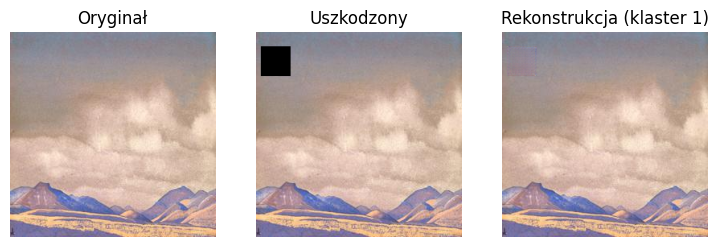

In [19]:
import matplotlib.pyplot as plt

sample_ds = WikiArtMaskedDataset(
    splits.test,
    image_size=data_cfg['image_size'],
    mask_type=mask_cfg['mask_type'],
    max_damage_ratio=mask_cfg['max_damage_ratio'],
    min_mask_size=mask_cfg['min_mask_size'],
    max_mask_size=mask_cfg['max_mask_size'],
    brush_width=mask_cfg['brush_width'],
    num_strokes=mask_cfg['num_strokes'],
    scale_images=True,
 )

image, mask, masked, _ = sample_ds[100]

autoencoder.eval()
with torch.no_grad():
    z = autoencoder.encode(image.unsqueeze(0).to(device))
    z_vec = z.mean(dim=(2, 3))
    z = z_vec.cpu().numpy()
    z_scaled = artifacts.scaler.transform(z)
    z_reduced = artifacts.pca.transform(z_scaled)

cluster_id = int(artifacts.model.predict(z_reduced)[0])
print('Wybrany klaster:', cluster_id)

cluster_model = SimpleUNet(inpaint_config).to(device)

cluster_model.load_state_dict(torch.load(f'models/inpaint_cluster_{cluster_id}.pth', map_location=device))
cluster_model.eval()

with torch.no_grad():
    output = cluster_model(image.unsqueeze(0).to(device), mask.unsqueeze(0).to(device))
    if isinstance(output, tuple):
        output = output[0]
    output = output.clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title('Oryginał')
axes[1].imshow(masked.permute(1, 2, 0))
axes[1].set_title('Uszkodzony')
axes[2].imshow(output.squeeze(0).cpu().permute(1, 2, 0))
axes[2].set_title(f'Rekonstrukcja (klaster {cluster_id})')
for ax in axes:
    ax.axis('off')
plt.show()


## 8. Pobranie modelu

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('models', 'zip', 'models')
files.download('models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>